Assignment Task:

Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.

Dataset Description:

The dataset consists of the following variables:

Age: Age in years

KM: Accumulated Kilometers on odometer

FuelType: Fuel Type (Petrol, Diesel, CNG)

HP: Horse Power

Automatic: Automatic ( (Yes=1, No=0)

CC: Cylinder Volume in cubic centimeters

Doors: Number of doors

Weight: Weight in Kilograms

Quarterly_Tax:

Price: Offer Price in EUROs


In [51]:
# importing pandas library to read the csv file
import pandas as pd

In [52]:
# Load the dataset
df=pd.read_csv('/content/ToyotaCorolla - MLR.csv')

In [53]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [54]:
df.shape

(1436, 11)

Taskes:

1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR.


In [55]:
# checking the missing values
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [56]:
# any duplicates
df.duplicated().sum()

1

In [57]:
# dropping the duplicates
df.drop_duplicates(inplace=True)

<Axes: >

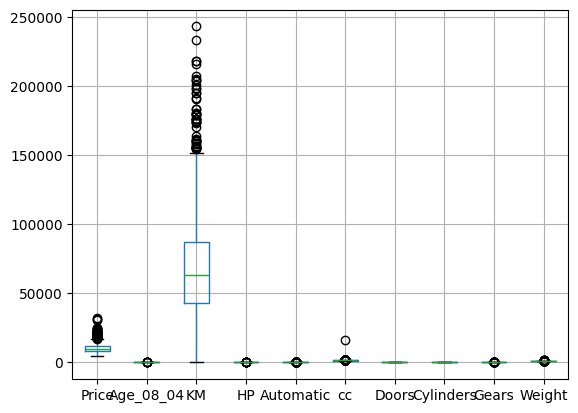

In [58]:
# outlier detection
df.boxplot()

In [59]:
# replacing the outlier by capping method
def outlier_capping(df,columns):
  Q1=df[columns].quantile(0.25)
  Q3=df[columns].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[columns]=df[columns].apply(lambda x:lower_bound if x<lower_bound else upper_bound if x>upper_bound else x)

for col in df.select_dtypes(include=['float','int']).columns:
  outlier_capping(df,col)


In [60]:
#correlation
num_col=df.select_dtypes(include=['float','int']).columns
num_col

Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight'],
      dtype='object')

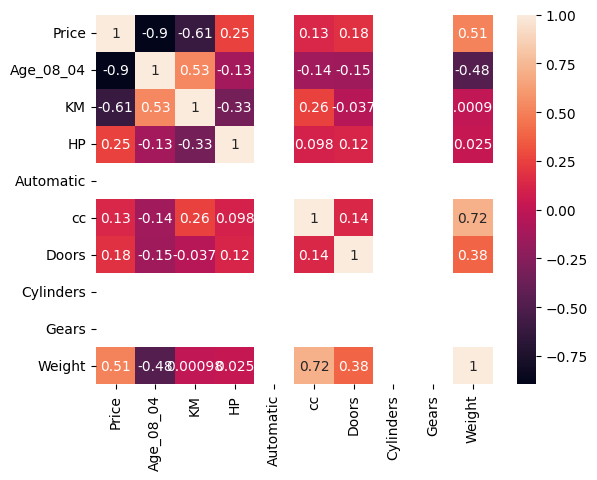

In [61]:
corr=df[num_col].corr()
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr,annot=True)
plt.show()

In [62]:
#dropping the unnecessary columns
df.drop(columns=['Automatic','Gears','Cylinders'],inplace=True)

In [63]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,cc,Doors,Weight
0,13500.0,23.0,46986.0,Diesel,90.0,1900.0,3,1152.5
1,13750.0,23.0,72937.0,Diesel,90.0,1900.0,3,1152.5
2,13950.0,24.0,41711.0,Diesel,90.0,1900.0,3,1152.5
3,14950.0,26.0,48000.0,Diesel,90.0,1900.0,3,1152.5
4,13750.0,30.0,38500.0,Diesel,90.0,1900.0,3,1152.5


In [64]:
# Labeling
df=pd.get_dummies(df,dtype='int')
df.head()

,Price,Age_08_04,KM,HP,cc,Doors,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500.0,23.0,46986.0,90.0,1900.0,3,1152.5,0,1,0
1,13750.0,23.0,72937.0,90.0,1900.0,3,1152.5,0,1,0
2,13950.0,24.0,41711.0,90.0,1900.0,3,1152.5,0,1,0
3,14950.0,26.0,48000.0,90.0,1900.0,3,1152.5,0,1,0
4,13750.0,30.0,38500.0,90.0,1900.0,3,1152.5,0,1,0


In [65]:
# scaling
from sklearn.preprocessing import StandardScaler
sta_sca=StandardScaler()
standardized_d=sta_sca.fit_transform(df)
df=pd.DataFrame(standardized_d,columns=df.columns)
df.head()

,Price,Age_08_04,KM,HP,cc,Doors,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,1.009230,-1.781129,-0.595118,-0.844145,2.024972,-1.084443,2.226997,-0.109493,2.884126,-2.718789
1,1.093220,-1.781129,0.152463,-0.844145,2.024972,-1.084443,2.226997,-0.109493,2.884126,-2.718789
2,1.160412,-1.727143,-0.747078,-0.844145,2.024972,-1.084443,2.226997,-0.109493,2.884126,-2.718789
3,1.496370,-1.619171,-0.565908,-0.844145,2.024972,-1.084443,2.226997,-0.109493,2.884126,-2.718789
4,1.093220,-1.403226,-0.839578,-0.844145,2.024972,-1.084443,2.226997,-0.109493,2.884126,-2.718789


In [66]:
# summary of the dataset
df.describe()

,Price,Age_08_04,KM,HP,cc,Doors,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
count,1.435000e+03,1.435000e+03,1.435000e+03,1.435000e+03,1.435000e+03,1.435000e+03,1.435000e+03,1.435000e+03,1.435000e+03,1.435000e+03
mean,-3.961214e-17,7.922428e-17,3.961214e-17,-5.298124e-16,-5.149578e-16,2.277698e-16,-2.059831e-15,-4.456366e-17,-3.961214e-17,1.386425e-16
std,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00,1.000349e+00
min,-2.064787e+00,-2.752880e+00,-1.948635e+00,-2.442128e+00,-1.531016e+00,-2.134494e+00,-1.817070e+00,-1.094930e-01,-3.467255e-01,-2.718789e+00
25%,-6.873585e-01,-6.474200e-01,-7.099448e-01,-8.441446e-01,-9.383512e-01,-1.084443e+00,-7.563309e-01,-1.094930e-01,-3.467255e-01,3.678108e-01
50%,-2.002191e-01,2.703446e-01,-1.208045e-01,6.777443e-01,2.469780e-01,-3.439192e-02,3.922332e-02,-1.094930e-01,-3.467255e-01,3.678108e-01
75%,4.884951e-01,7.562200e-01,5.587767e-01,6.777443e-01,2.469780e-01,1.015659e+00,4.370004e-01,-1.094930e-01,-3.467255e-01,3.678108e-01
max,2.252276e+00,1.296082e+00,2.461859e+00,2.960578e+00,2.024972e+00,1.015659e+00,2.226997e+00,9.133004e+00,2.884126e+00,3.678108e-01


2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [67]:
#target is price
target=df[['Price']]

#The rest are features
features=df.drop(columns='Price')

In [68]:
# splitting the data

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.7,random_state=100)

In [69]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1004, 9)
(1004, 1)
(431, 9)
(431, 1)


3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build minimum of 3 different models.

Model 1

In [70]:
from sklearn.linear_model import LinearRegression

lin_model=LinearRegression()

In [71]:
# training the model
lin_model.fit(x_train,y_train)

LinearRegression()

In [72]:
y_pred1=lin_model.predict(x_test)

Model 2

In [73]:
x_train2,x_test2,y_train2,y_test2=train_test_split(features,target,train_size=0.75,random_state=100)

In [74]:
lin_model2=LinearRegression()

In [75]:
lin_model2.fit(x_train2,y_train2)

LinearRegression()

In [76]:
y_pred2=lin_model2.predict(x_test2)

Model 3

In [77]:
x_train3,x_test3,y_train3,y_test3=train_test_split(features,target,train_size=0.8,random_state=100)

In [78]:
lin_model3=LinearRegression()

In [79]:
lin_model3.fit(x_train3,y_train3)

LinearRegression()

In [80]:
y_pred3=lin_model3.predict(x_test3)

4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [81]:
from sklearn.metrics import r2_score
#accuracy score for model1
r2_score(y_test,y_pred1)

0.8583011072937421

In [82]:
# accuracy score for model2
r2_score(y_test2,y_pred2)

0.8565771907968607

In [83]:
# accuracy score for model3
r2_score(y_test3,y_pred3)

0.8505975113400095

In [84]:
# compared to all the three models, model 1 has highest accuracy

5.Apply Lasso and Ridge methods on the model.

In [85]:
# Lasso Model

from sklearn.linear_model import Lasso,Ridge
from sklearn.model_selection import GridSearchCV
lasso=Lasso()

In [86]:
# gridsearch to find the best alpha value
params={'alpha':[0,1,2,3,4,5]}

In [87]:
grid_search=GridSearchCV(lasso,params)

In [88]:
import warnings
warnings.filterwarnings('ignore')
grid_search.fit(x_train,y_train)

GridSearchCV(estimator=Lasso(), param_grid={'alpha': [0, 1, 2, 3, 4, 5]})

In [89]:
grid_search.best_params_

{'alpha': 0}

In [90]:
lasso=Lasso(alpha=0)

In [91]:
lasso.fit(x_train,y_train)

Lasso(alpha=0)

In [92]:
y_predict_lasso=lasso.predict(x_test)

In [93]:
r2_score(y_test,y_predict_lasso)

0.858301107293742

In [94]:
# Ridge Model

ridge=Ridge(alpha=0)

In [95]:
ridge.fit(x_train,y_train)

Ridge(alpha=0)

In [96]:
y_predict_ridge=ridge.predict(x_test)

In [97]:
r2_score(y_test,y_predict_ridge)

0.8563437346431236

Interview Questions:

1.What is Normalization & Standardization and how is it helpful?


In [98]:
# Normalization

'''
Normalization is one of the scaling techinques in th exploratory data analysis.
It is also called as min-max scaler.
It ranges from 0 to 1.
Normalization=(x_i-x_min)/(x_max-x_min).
'''

# Standardization
'''
Standardization is one of the scaling techinques in th exploratory data analysis.
It ranges from -3 to 3.
Standardization=(x_i-mu)/sigma.
'''
'''
Both helps to transform the data to the same scale or standard form.
It makes the model learn the data in a easy and effective manner.
'''

'\nBoth helps to transform the data to the same scale or standard form.\nIt makes the model learn the data in a easy and effective manner.\n'

What techniques can be used to address multicollinearity in multiple linear regression?

In [99]:
'''
The techniques used to address multicollinearity in multiple linear regression are
     1. VIF - Variance Inflation Factor
            - If the VIF>5 , then features has multicollinearity
            - It is only applied to features.

      2. Correlation
            - It gives the relationship between the features and alse with target.
            - If it has high values then it has multicollinearity.
'''

'\nThe techniques used to address multicollinearity in multiple linear regression are\n     1. VIF - Variance Inflation Factor\n            - If the VIF>5 , then features has multicollinearity\n            - It is only applied to features.\n\n      2. Correlation \n            - It gives the relationship between the features and alse with target.\n            - If it has high values then it has multicollinearity.\n'